In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('../data/smoking.csv')
df

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,94.0,215.0,82.0,73.0,126.0,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,130.0,192.0,115.0,42.0,127.0,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,89.0,242.0,182.0,55.0,151.0,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,96.0,322.0,254.0,45.0,226.0,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,80.0,184.0,74.0,62.0,107.0,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55687,55676,F,40,170,65,75.0,0.9,0.9,1.0,1.0,110.0,68.0,89.0,213.0,99.0,75.0,118.0,12.3,1.0,0.6,14.0,7.0,10.0,Y,1,Y,0
55688,55681,F,45,160,50,70.0,1.2,1.2,1.0,1.0,101.0,62.0,89.0,166.0,69.0,73.0,79.0,14.0,1.0,0.9,20.0,12.0,14.0,Y,0,Y,0
55689,55683,F,55,160,50,68.5,1.0,1.2,1.0,1.0,117.0,72.0,88.0,158.0,77.0,79.0,63.0,12.4,1.0,0.5,17.0,11.0,12.0,Y,0,N,0
55690,55684,M,60,165,60,78.0,0.8,1.0,1.0,1.0,133.0,76.0,107.0,210.0,79.0,48.0,146.0,14.4,1.0,0.7,20.0,19.0,18.0,Y,0,N,0


In [3]:
df.info

<bound method DataFrame.info of           ID gender  age  height(cm)  weight(kg)  waist(cm)  eyesight(left)  \
0          0      F   40         155          60       81.3             1.2   
1          1      F   40         160          60       81.0             0.8   
2          2      M   55         170          60       80.0             0.8   
3          3      M   40         165          70       88.0             1.5   
4          4      F   40         155          60       86.0             1.0   
...      ...    ...  ...         ...         ...        ...             ...   
55687  55676      F   40         170          65       75.0             0.9   
55688  55681      F   45         160          50       70.0             1.2   
55689  55683      F   55         160          50       68.5             1.0   
55690  55684      M   60         165          60       78.0             0.8   
55691  55691      M   55         160          65       85.0             0.9   

       eyesight(rig

In [4]:
df.shape

(55692, 27)

In [5]:
df.isnull().sum().sort_values(ascending=False)

ID                     0
triglyceride           0
tartar                 0
dental caries          0
oral                   0
Gtp                    0
ALT                    0
AST                    0
serum creatinine       0
Urine protein          0
hemoglobin             0
LDL                    0
HDL                    0
Cholesterol            0
gender                 0
fasting blood sugar    0
relaxation             0
systolic               0
hearing(right)         0
hearing(left)          0
eyesight(right)        0
eyesight(left)         0
waist(cm)              0
weight(kg)             0
height(cm)             0
age                    0
smoking                0
dtype: int64

In [6]:
column_mapping = {
    'ID': 'id',
    'gender': '성별',
    'age': '연령',
    'height(cm)': '신장',
    'weight(kg)': '체중',
    'waist(cm)': '허리둘레',
    'eyesight(left)': '시력_좌',
    'eyesight(right)': '시력_우',
    'hearing(left)': '청력_좌',
    'hearing(right)': '청력_우',
    'systolic': '수축기혈압',
    'relaxation': '이완기혈압',
    'fasting blood sugar': '공복혈당',
    'Cholesterol': '총콜레스테롤',
    'triglyceride': '트리글리세라이드',
    'HDL': 'HDL콜레스테롤',
    'LDL': 'LDL콜레스테롤',
    'hemoglobin': '혈색소',
    'Urine protein': '요단백',
    'serum creatinine': '혈청크레아티닌',
    'AST': 'AST',
    'ALT': 'ALT',
    'Gtp': '감마지티피',
    'oral': '구강검사여부',
    'dental caries': '치아우식증',
    'tartar': '치석',
    'smoking': '흡연여부'
}


In [7]:
df = df.rename(columns=column_mapping)
df.columns.tolist()

['id',
 '성별',
 '연령',
 '신장',
 '체중',
 '허리둘레',
 '시력_좌',
 '시력_우',
 '청력_좌',
 '청력_우',
 '수축기혈압',
 '이완기혈압',
 '공복혈당',
 '총콜레스테롤',
 '트리글리세라이드',
 'HDL콜레스테롤',
 'LDL콜레스테롤',
 '혈색소',
 '요단백',
 '혈청크레아티닌',
 'AST',
 'ALT',
 '감마지티피',
 '구강검사여부',
 '치아우식증',
 '치석',
 '흡연여부']

In [8]:
df['성별'] = df['성별'].map({'M': '남', 'F': '여'})

In [9]:
df['구강검사여부'] = df['구강검사여부'].map({'Y': 1, 'N': 0})
df['치석'] = df['치석'].map({'Y': 1, 'N': 0})

df[['성별', '구강검사여부', '치아우식증', '치석', '흡연여부']].head()

,성별,구강검사여부,치아우식증,치석,흡연여부
0,여,1,0,1,0
1,여,1,0,1,0
2,남,1,0,0,1
3,남,1,0,1,0
4,여,1,0,0,0


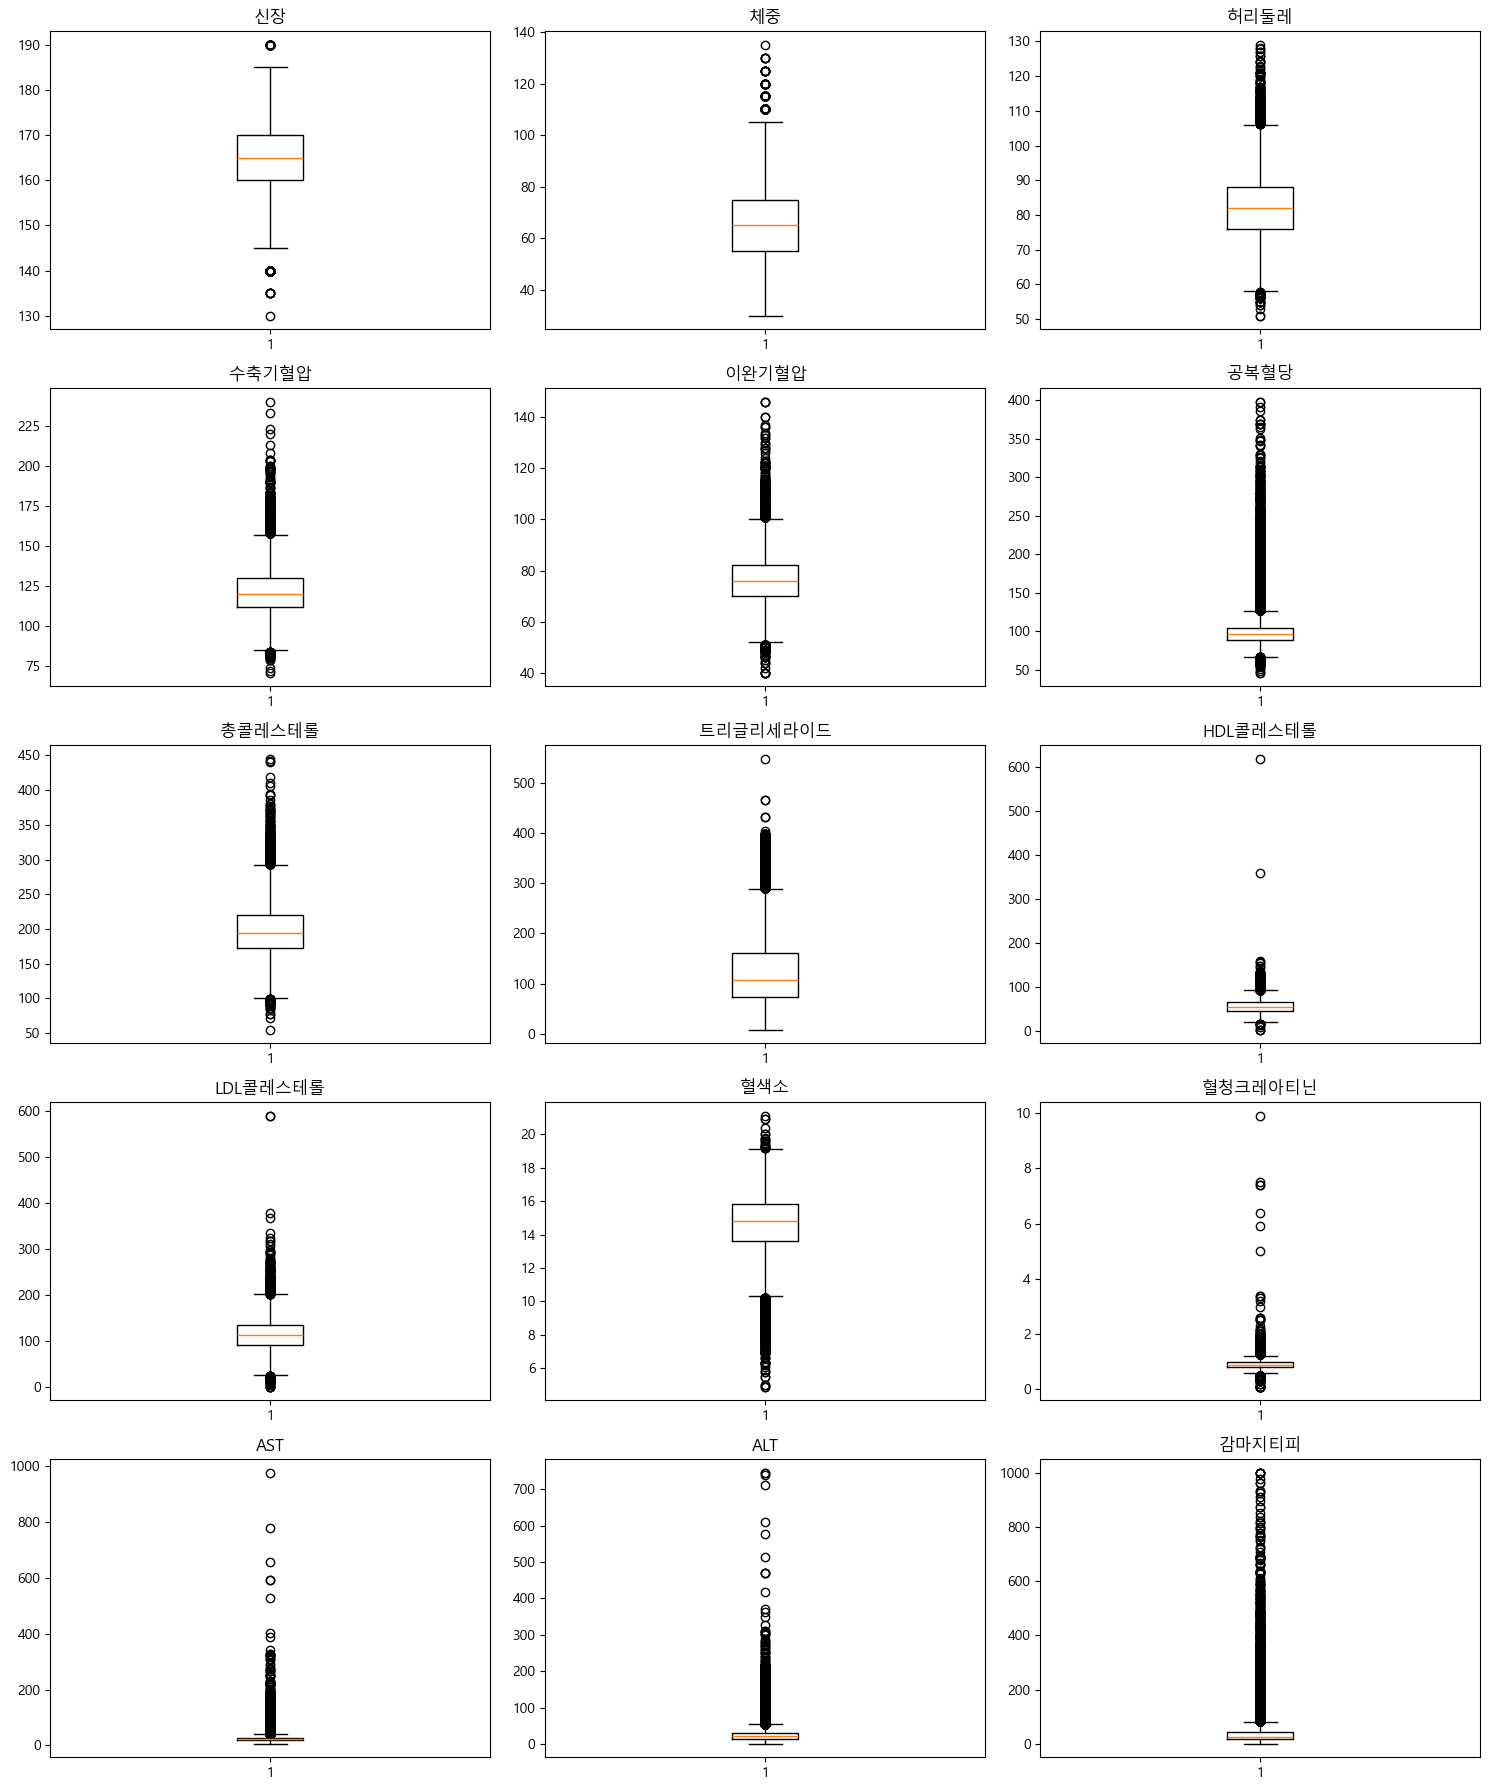

In [22]:
numeric_cols = ['신장', '체중', '허리둘레', '수축기혈압', '이완기혈압',
                 '공복혈당', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤',
                 'LDL콜레스테롤', '혈색소', '혈청크레아티닌', 'AST', 'ALT', '감마지티피']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../results/figures/boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


boxplot을 쓴 이유는 IQR 기반 이상치를 한눈에 시각적으로 확인하기 위해서

In [11]:
def count_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = {col: count_outliers_iqr(df[col]) for col in numeric_cols}
pd.Series(outlier_summary).sort_values(ascending=False)


감마지티피       5019
ALT         3710
AST         3699
공복혈당        3298
혈청크레아티닌     3147
트리글리세라이드    2256
HDL콜레스테롤    1011
이완기혈압        706
수축기혈압        685
혈색소          669
LDL콜레스테롤     634
총콜레스테롤       605
허리둘레         496
신장           249
체중           198
dtype: int64

In [12]:
df[['AST', 'ALT', '감마지티피']].sort_values('감마지티피', ascending=False).head(10)

,AST,ALT,감마지티피
14797,69.0,40.0,999.0
6753,166.0,114.0,999.0
35037,185.0,196.0,999.0
31636,124.0,83.0,999.0
33234,210.0,119.0,999.0
16443,101.0,141.0,976.0
55430,184.0,81.0,961.0
35474,184.0,81.0,961.0
44446,124.0,59.0,933.0
48118,124.0,59.0,933.0


In [13]:
before_shape = df.shape[0]

df = df[
    (df['수축기혈압'].between(70, 250)) &
    (df['이완기혈압'].between(40, 150)) &
    (df['공복혈당'].between(40, 400)) &
    (df['AST'] < 1000) &
    (df['ALT'] < 1000) &
    (df['감마지티피'] < 1000) &
    (df['LDL콜레스테롤'] < 600) &
    (df['트리글리세라이드'] < 600) &
    (df['혈청크레아티닌'] < 10)
]

after_shape = df.shape[0]
print(f"전: {before_shape},후: {after_shape}, 제거된 행: {before_shape - after_shape}")

전: 55692,후: 55653, 제거된 행: 39


In [14]:
df[['시력_좌', '시력_우']].describe()
print((df['시력_좌'] >= 9).sum(), (df['시력_우'] >= 9).sum())

df['시력_좌'] = df['시력_좌'].replace(9.9, np.nan)
df['시력_우'] = df['시력_우'].replace(9.9, np.nan)

print(df['시력_좌'].isnull().sum(), df['시력_우'].isnull().sum())

91 92
91 92


In [15]:
df['BMI'] = df['체중'] / ((df['신장'] / 100) ** 2)
df['BMI'].describe()

count    55653.000000
mean        24.165954
std          3.477850
min         14.268728
25%         21.604938
50%         23.875115
75%         26.122449
max         42.448980
Name: BMI, dtype: float64

In [16]:
def is_high_waist(row):
    if row['성별'] == '남':
        return row['허리둘레'] >= 90
    else:
        return row['허리둘레'] >= 85

def is_low_hdl(row):
    if row['성별'] == '남':
        return row['HDL콜레스테롤'] < 40
    else:
        return row['HDL콜레스테롤'] < 50

In [17]:
df['기준_허리둘레'] = df.apply(is_high_waist, axis=1)
df['기준_혈압'] = (df['수축기혈압'] >= 130) | (df['이완기혈압'] >= 85)
df['기준_혈당'] = df['공복혈당'] >= 100
df['기준_트리글리세라이드'] = df['트리글리세라이드'] >= 150
df['기준_HDL'] = df.apply(is_low_hdl, axis=1)

df['대사증후군_점수'] = (
    df['기준_허리둘레'].astype(int) +
    df['기준_혈압'].astype(int) +
    df['기준_혈당'].astype(int) +
    df['기준_트리글리세라이드'].astype(int) +
    df['기준_HDL'].astype(int)
)

df['대사증후군_위험군'] = (df['대사증후군_점수'] >= 3).astype(int)
df['대사증후군_위험군'].value_counts(normalize=True)

대사증후군_위험군
0    0.817296
1    0.182704
Name: proportion, dtype: float64

In [18]:
print(df.shape)
df.isnull().sum().sort_values(ascending=False).head(10)
df.head()


(55653, 35)


,id,성별,연령,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,공복혈당,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,AST,ALT,감마지티피,구강검사여부,치아우식증,치석,흡연여부,BMI,기준_허리둘레,기준_혈압,기준_혈당,기준_트리글리세라이드,기준_HDL,대사증후군_점수,대사증후군_위험군
0,0,여,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,94.0,215.0,82.0,73.0,126.0,12.9,1.0,0.7,18.0,19.0,27.0,1,0,1,0,24.973985,False,False,False,False,False,0,0
1,1,여,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,130.0,192.0,115.0,42.0,127.0,12.7,1.0,0.6,22.0,19.0,18.0,1,0,1,0,23.437500,False,False,True,False,True,2,0
2,2,남,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,89.0,242.0,182.0,55.0,151.0,15.8,1.0,1.0,21.0,16.0,22.0,1,0,0,1,20.761246,False,True,False,True,False,2,0
3,3,남,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,96.0,322.0,254.0,45.0,226.0,14.7,1.0,1.0,19.0,26.0,18.0,1,0,1,0,25.711662,False,False,False,True,False,1,0
4,4,여,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,80.0,184.0,74.0,62.0,107.0,12.5,1.0,0.6,16.0,14.0,22.0,1,0,0,0,24.973985,True,False,False,False,False,1,0


In [19]:
df.to_csv('../data/processed.csv', index=False)
print("저장: data/processed.csv")

저장: data/processed.csv
